# Transit fit — the radius of Kepler-8 b

The exploratory narrative. We load a real Kepler light curve, fold it on the known
period, fit a trapezoid to the transit, and read off **Rp/R\***. Read this top to
bottom to see the *thinking*; the trusted version of each step lives in
`scripts/transit.py` and is checked by `tests/test_transit.py`.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt

arr = np.loadtxt("data/real/kepler8_q3.csv", delimiter=",", skiprows=1)
time, flux, flux_err = arr[:, 0], arr[:, 1], arr[:, 2]
print(len(time), "points over", round(np.ptp(time), 1), "days")

4070 points over 88.7 days


## 1. Look at the raw light curve

Always plot the data before you model it. The transits are the periodic dips —
hard to see individually in the full series, which is exactly why we fold.

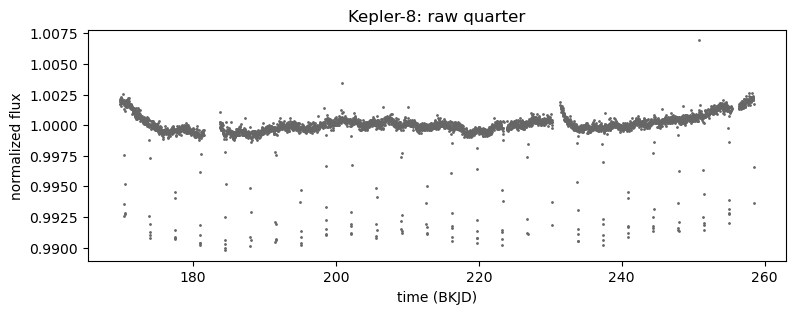

In [2]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(time, flux, ".", ms=2, color="0.4")
ax.set_xlabel("time (BKJD)"); ax.set_ylabel("normalized flux")
ax.set_title("Kepler-8: raw quarter"); plt.show()

## 2. Fold on the known period

Kepler-8 b orbits every **P = 3.52254 d** (Jenkins et al. 2010). Folding wraps every
orbit onto one, stacking ~25 shallow transits into a single well-sampled dip. The
transit-center epoch `t0` we take from a Box-Least-Squares search (see notes).

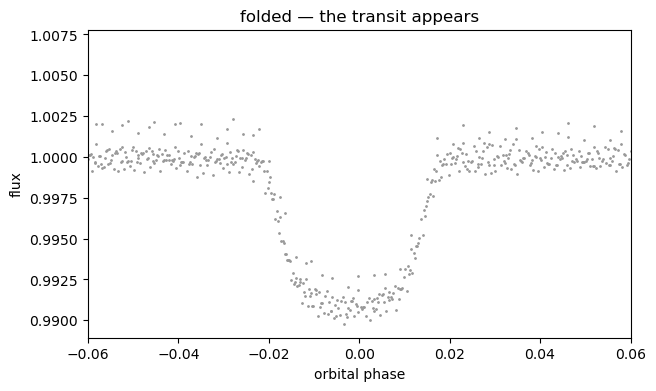

In [3]:
from scripts.transit import phase_fold
P, T0 = 3.52254, 170.4408
phase = phase_fold(time, P, T0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(phase, flux, ".", ms=2, color="0.6")
ax.set_xlim(-0.06, 0.06); ax.set_xlabel("orbital phase"); ax.set_ylabel("flux")
ax.set_title("folded — the transit appears"); plt.show()

## 3. Fit the transit

We fit a **trapezoid** (flat bottom + linear ingress/egress). The fitted depth δ gives
the radius ratio for a uniform star: **Rp/R\* = √δ**. We import the trusted function
from the script rather than re-deriving it here — notebooks think, scripts are trusted.

In [4]:
from scripts.transit import fit_transit
res = fit_transit(time, flux, flux_err, period=P, t0=T0, window=0.06)
print(f"depth = {res['depth']:.5f}   ->   Rp/R* = {res['rp_over_rstar']:.4f}")
print("literature Rp/R* = 0.0944  (Jenkins et al. 2010)")

depth = 0.00875   ->   Rp/R* = 0.0935
literature Rp/R* = 0.0944  (Jenkins et al. 2010)


## 4. Inspect the residuals

The number means nothing until we've *looked*. Plot data − model: structureless
residuals are the evidence the fit is good. (The faint dip remaining at mid-transit
is **limb darkening** — a real star is brighter at center, so the true transit is a
touch deeper and rounder than a flat-bottomed trapezoid. That ~1% effect is why our
0.0935 sits just under the literature 0.0944.)

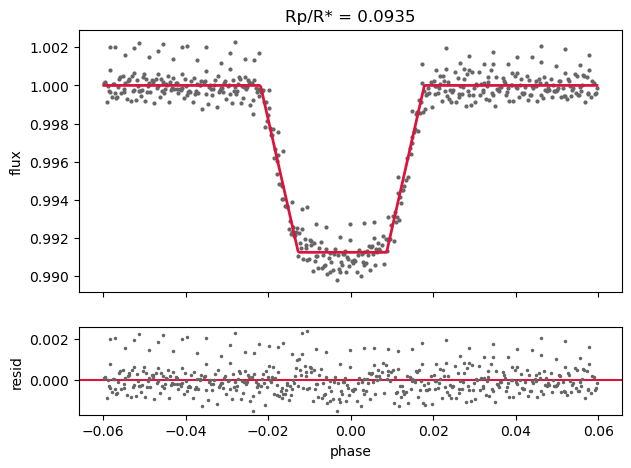

In [5]:
ph, fl, model = res["phase"], res["flux"], res["model"]
fig, (a0, a1) = plt.subplots(2, 1, figsize=(7, 5), height_ratios=[3, 1], sharex=True)
a0.plot(ph, fl, ".", ms=4, color="0.4"); a0.plot(ph, model, "-", color="crimson", lw=2)
a0.set_ylabel("flux"); a0.set_title(f"Rp/R* = {res['rp_over_rstar']:.4f}")
a1.axhline(0, color="crimson"); a1.plot(ph, fl - model, ".", ms=3, color="0.4")
a1.set_ylabel("resid"); a1.set_xlabel("phase"); plt.show()

## 5. Cross-check against `batman`

`batman` is the community-standard transit code (Mandel & Agol 2002). For a *uniform*
source the depth equals (Rp/R\*)² exactly, so feeding batman a known `rp` and running
our estimator on its output should return that `rp`. This is the hard check in
`tests/test_transit.py::test_agrees_with_batman`.

In [6]:
import batman
rp_true = 0.1
pp = batman.TransitParams()
pp.t0, pp.per, pp.rp, pp.a = 1.0, 3.0, rp_true, 12.0
pp.inc, pp.ecc, pp.w = 90.0, 0.0, 90.0
pp.u, pp.limb_dark = [], "uniform"
tt = np.linspace(0, 3, 2000)
ff = batman.TransitModel(pp, tt).light_curve(pp)
out = fit_transit(tt, ff, np.full_like(ff, 1e-4), period=3.0, t0=1.0)
print(f"batman input Rp/R* = {rp_true};  recovered = {out['rp_over_rstar']:.4f}")

batman input Rp/R* = 0.1;  recovered = 0.1000


## Result

**Rp/R\* = 0.094 for Kepler-8 b** — a Jupiter-sized planet, matching the literature.
The estimator recovers a known synthetic depth and agrees with `batman`; see
`notes/HANDOFF_transit.md` for the full summary.